In [1]:
%load_ext autoreload
%autoreload 2

# PIT Histograms of Model Predictions (Test Set)

Compute and plot PIT (Probability Integral Transform) histograms for all models
on the test set, compared against the raw IFS ensemble. A well-calibrated
probabilistic forecast produces uniformly distributed PIT values.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr

from genpp.data.weatherbench2 import (
    FC_VARS,
    FORECAST_ENS_PATH,
    OBSERVATIONS_FLAT_PATH,
    TEST_PREDICTIONS,
)
from genpp.eval import best_models
from genpp.eval.utils import load_predictions_dataarray
from genpp.plots import RESULTS_DIR

sns.set_style("whitegrid")

## Load Observations and Raw Ensemble

In [3]:
# Ground-truth observations
valid_times = TEST_PREDICTIONS.get_level_values("time") + TEST_PREDICTIONS.get_level_values(
    "prediction_timedelta"
)
obs = (
    xr.open_dataset(OBSERVATIONS_FLAT_PATH)[FC_VARS]
    .sel(time=valid_times)
    .to_dataarray("feature")
    .sel(feature=FC_VARS)
    .transpose("time", "feature", "longitude", "latitude")
)
print("Observations shape:", obs.shape)

# Raw IFS ensemble
raw = (
    xr.open_dataset(FORECAST_ENS_PATH)[FC_VARS]
    .sel(
        time=TEST_PREDICTIONS.get_level_values("time").unique(),
        prediction_timedelta=TEST_PREDICTIONS.get_level_values("prediction_timedelta").unique(),
    )
    .stack(prediction=["time", "prediction_timedelta"])
    .sel(prediction=TEST_PREDICTIONS)
    .rename({"number": "sample"})
    .to_dataarray("feature")
    .transpose("prediction", "sample", "feature", "latitude", "longitude")
)
print("Raw ensemble shape:", raw.shape)

Observations shape: (3620, 2, 37, 31)
Raw ensemble shape: (3620, 50, 2, 31, 37)


## Load Model Predictions

In [4]:
# Discover and load test-set predictions for all models
model_predictions: dict[str, dict[str, xr.DataArray]] = {}

for model_name, model_entries in best_models:
    if not model_entries:
        continue
    model_predictions[model_name] = {}

    # For EMOS and DRN: only load ECC and GCA copula variants
    if model_name in ("emos", "drn"):
        entry = model_entries[0]
        for copula_tag, copula_file in [
            ("ecc", "test_predictions_ecc.zarr"),
            ("gca", "test_predictions_gca.zarr"),
        ]:
            try:
                copula_path = entry.model_dir / copula_file
                if not copula_path.exists():
                    found = list(entry.model_dir.rglob(copula_file))
                    if not found:
                        print(f"  ✗ {model_name}/{copula_tag}: {copula_file} not found")
                        continue
                    copula_path = found[0]
                preds = load_predictions_dataarray(copula_path).sel(prediction=TEST_PREDICTIONS)
                model_predictions[model_name][copula_tag] = preds
                n_samples = preds.sizes.get("sample", 1)
                print(f"  ✓ {model_name}/{copula_tag}: {preds.shape}  ({n_samples} samples)")
            except Exception as e:
                print(f"  ✗ {model_name}/{copula_tag}: {e}")
    else:
        # All other models: load test_predictions variants
        for entry in model_entries:
            variant_key = entry.tag or "standard"
            try:
                pred_files = list(entry.model_dir.rglob("test_predictions*.zarr"))
                if not pred_files:
                    print(f"  ✗ {model_name}/{variant_key}: no prediction file found")
                    continue
                preds = load_predictions_dataarray(pred_files[0]).sel(prediction=TEST_PREDICTIONS)
                model_predictions[model_name][variant_key] = preds
                n_samples = preds.sizes.get("sample", 1)
                print(f"  ✓ {model_name}/{variant_key}: {preds.shape}  ({n_samples} samples)")
            except Exception as e:
                print(f"  ✗ {model_name}/{variant_key}: {e}")

print(f"\nLoaded models: {list(model_predictions.keys())}")
for mname, variants in model_predictions.items():
    print(f"  {mname}: {list(variants.keys())}")

  ✓ emos/ecc: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ emos/gca: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ drn/ecc: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ drn/gca: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ chen/ind_es: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ chen/ind_pes: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ chen/ind_mses: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ chen/ind_mspes: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ chen/dir_es: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ chen/dir_pes: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ chen/dir_mses: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ chen/dir_mspes: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ fm/ind_unet: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ fm/dir_unet: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ fm/ind_uvit: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ fm/dir_uvit: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ engression/ind_es: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ engression/ind_pes: (3620, 50, 2, 37, 31)  (50 samples)
  ✓ engression/ind_mses: (3620, 50,

## Plot PIT Histograms per Variable

For each forecast variable we plot a PIT histogram for the raw ensemble and every
post-processed model variant. The PIT value for each grid point / time is the
fraction of ensemble members below the observation. A uniform histogram indicates
perfect calibration.

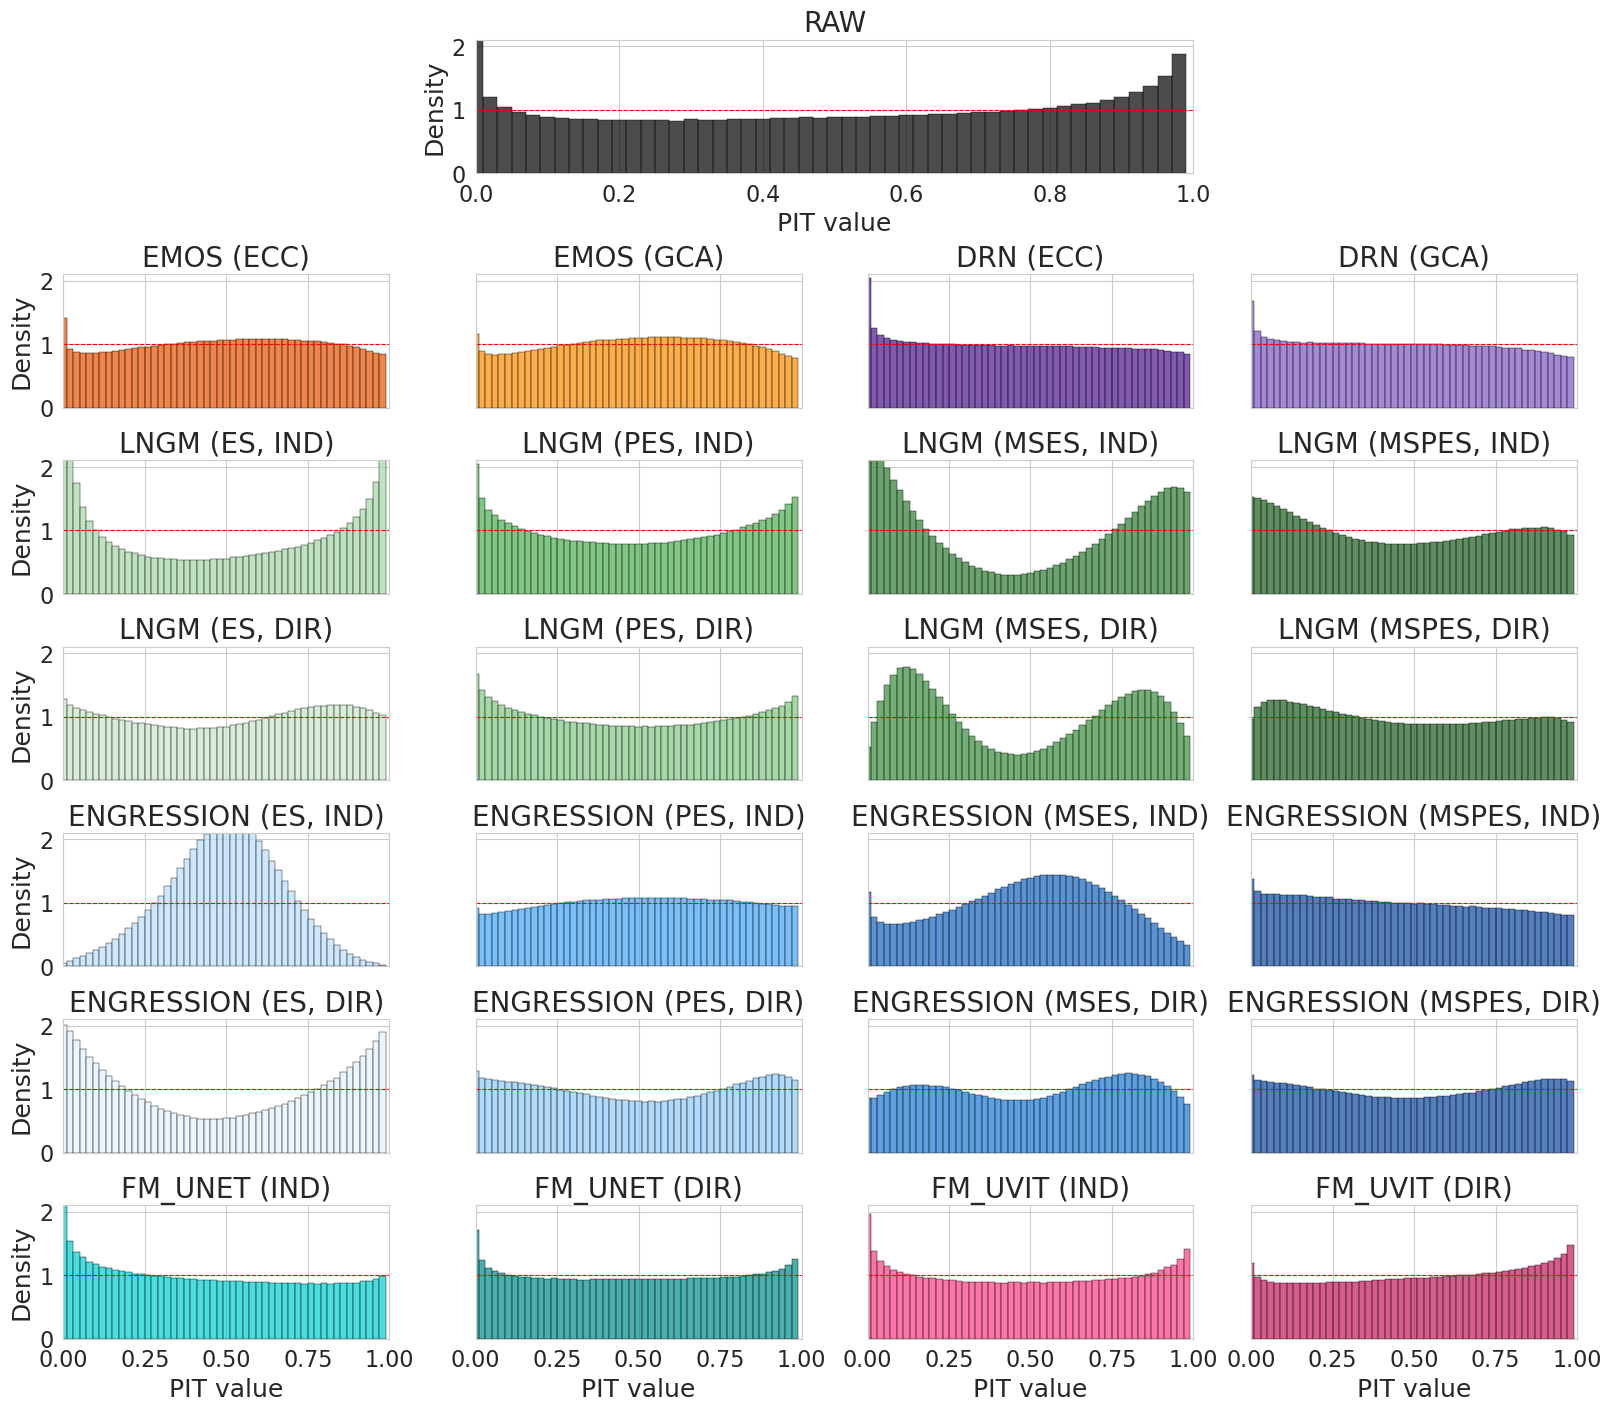

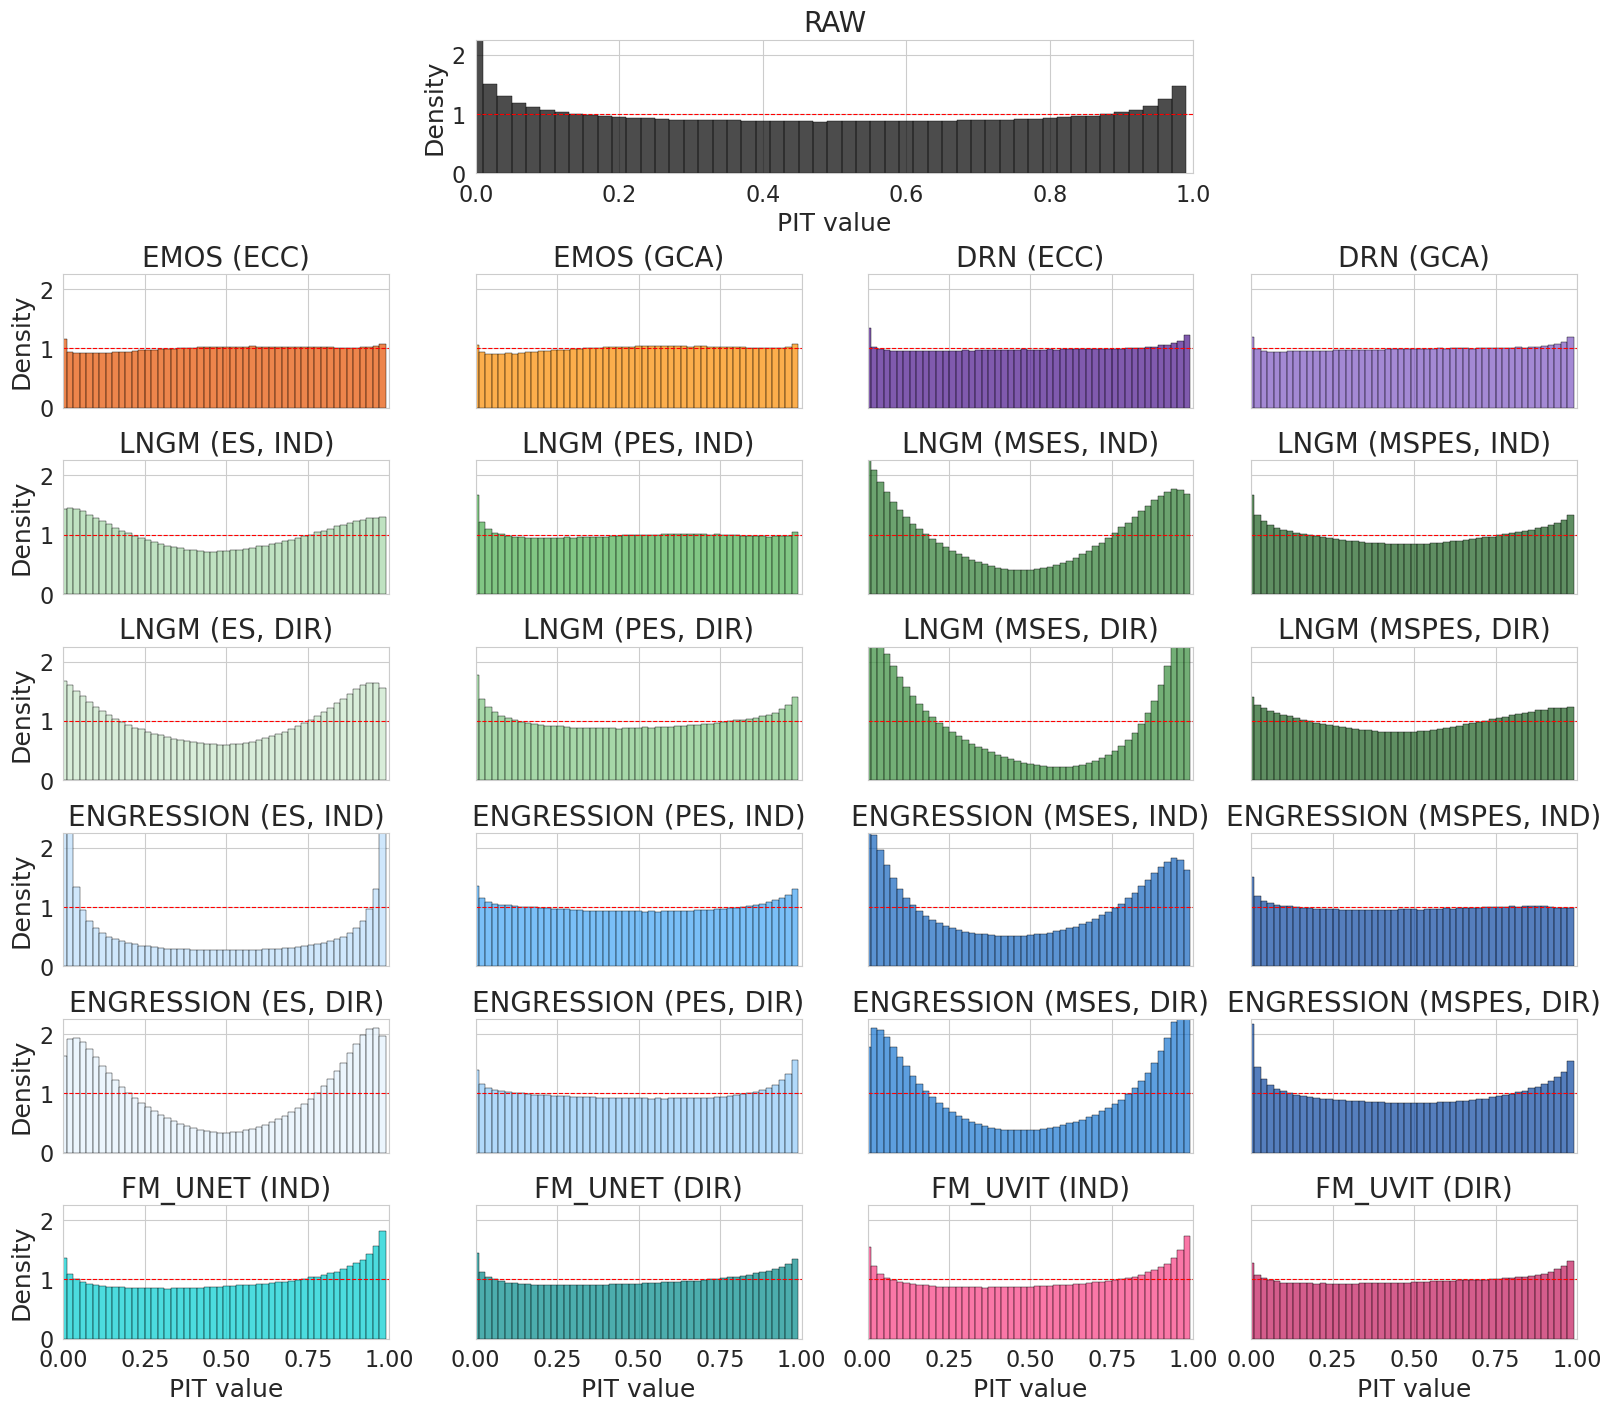

In [ ]:
from matplotlib.gridspec import GridSpec

VAR_DISPLAY = {
    "2m_temperature": "2m Temperature (K)",
    "10m_wind_speed": "10m Wind Speed (m/s)",
}

# Per-variant color mapping (each variant has its own shade within the family)
color_mapping = {
    "RAW": "black",
    "EMOS (ECC)": "#E65100",
    "EMOS (GCA)": "#FB8C00",
    "DRN (ECC)": "#4A148C",
    "DRN (GCA)": "#7E57C2",
    "LNGM (ES, IND)": "#A5D6A7",
    "LNGM (PES, IND)": "#4CAF50",
    "LNGM (MSES, IND)": "#2E7D32",
    "LNGM (MSPES, IND)": "#1B5E20",
    "LNGM (ES, DIR)": "#C8E6C9",
    "LNGM (PES, DIR)": "#81C784",
    "LNGM (MSES, DIR)": "#388E3C",
    "LNGM (MSPES, DIR)": "#1B5E20",
    "ENGRESSION (ES, IND)": "#BBDEFB",
    "ENGRESSION (PES, IND)": "#42A5F5",
    "ENGRESSION (MSES, IND)": "#1565C0",
    "ENGRESSION (MSPES, IND)": "#0D47A1",
    "ENGRESSION (ES, DIR)": "#E3F2FD",
    "ENGRESSION (PES, DIR)": "#90CAF9",
    "ENGRESSION (MSES, DIR)": "#1976D2",
    "ENGRESSION (MSPES, DIR)": "#0D47A1",
    "FM_UNET (IND)": "#00CED1",
    "FM_UNET (DIR)": "#008B8B",
    "FM_UVIT (IND)": "#F83E82",
    "FM_UVIT (DIR)": "#C2185B",
}

MODEL_DISPLAY = {
    "emos": "EMOS",
    "drn": "DRN",
    "chen": "LNGM",
    "engression": "ENGRESSION",
    "fm": "FM",
}

# Variant key → display string
VARIANT_DISPLAY = {
    "ecc": "ECC",
    "gca": "GCA",
    "ind_es": "ES, IND",
    "ind_pes": "PES, IND",
    "ind_mses": "MSES, IND",
    "ind_mspes": "MSPES, IND",
    "dir_es": "ES, DIR",
    "dir_pes": "PES, DIR",
    "dir_mses": "MSES, DIR",
    "dir_mspes": "MSPES, DIR",
    "ind_unet": "IND",
    "ind_uvit": "IND",
    "dir_unet": "DIR",
    "dir_uvit": "DIR",
    "standard": None,
}

# Order for sorting: FM models come last
_MODEL_ORDER = {"emos": 0, "drn": 1, "chen": 2, "engression": 3, "fm": 9}

TITLE_FS = 20
LABEL_FS = 18
TICK_FS = 16


def make_display_label(model_name: str, variant_key: str) -> str:
    """Build a display label matching the 02plot_scores convention."""
    model_disp = MODEL_DISPLAY.get(model_name, model_name.upper())
    variant_disp = VARIANT_DISPLAY.get(variant_key, variant_key.upper())
    # FM models: FM_UNET (IND) / FM_UVIT (DIR) etc.
    if model_name == "fm":
        if "unet" in variant_key:
            base = "FM_UNET"
        elif "uvit" in variant_key:
            base = "FM_UVIT"
        else:
            return model_disp
        if variant_disp:
            return f"{base} ({variant_disp})"
        return base
    if variant_disp:
        return f"{model_disp} ({variant_disp})"
    return model_disp


def compute_pit(ensemble: np.ndarray, observation: np.ndarray) -> np.ndarray:
    """Compute randomized PIT values from ensemble samples and observations.

    Args:
        ensemble: Array of shape (..., n_samples) — samples on the LAST axis.
        observation: Array of shape (...) matching all non-sample dims of ensemble.

    Returns:
        Array of PIT values in [0, 1] with the same shape as observation.
    """
    obs_expanded = observation[..., np.newaxis]
    n_below = np.sum(ensemble < obs_expanded, axis=-1)
    n_equal = np.sum(ensemble == obs_expanded, axis=-1)
    n_samples = ensemble.shape[-1]
    rng = np.random.default_rng(42)
    u = rng.uniform(size=n_below.shape)
    pit = (n_below + u * n_equal) / n_samples
    return pit


def robust_hist_ylim(
    all_pit_arrays: list[np.ndarray], bins: np.ndarray, margin: float = 0.4
) -> float:
    """Compute a shared y-limit from the 95th percentile of bar heights across all panels."""
    all_heights = []
    for pit_vals in all_pit_arrays:
        counts, _ = np.histogram(pit_vals, bins=bins, density=True)
        all_heights.extend(counts.tolist())
    # Use the 95th percentile to exclude outlier bars
    ylim = float(np.percentile(all_heights, 95))
    return ylim * (1 + margin)


N_PIT_BINS = 50
SPATIAL_DIMS = ("latitude", "longitude")

# Shift bin edges by half a bin width so they fall *between* PIT values (k/n_samples).
PIT_BINS = (np.arange(N_PIT_BINS + 1) - 0.5) / N_PIT_BINS

for var in FC_VARS:
    display_name = VAR_DISPLAY.get(var, var)

    # Observation: align to (prediction, lat, lon)
    obs_var = obs.sel(feature=var).rename({"time": "prediction"})
    obs_for_pit = obs_var.transpose("prediction", *SPATIAL_DIMS).values

    # Raw ensemble: move sample to last axis → (prediction, lat, lon, sample)
    raw_var = raw.sel(feature=var).transpose("prediction", *SPATIAL_DIMS, "sample").values
    raw_pit = compute_pit(raw_var, obs_for_pit).ravel()

    # Collect all model variants into a flat list, keeping model_name for sorting
    model_items_unsorted: list[tuple[str, str, np.ndarray]] = []
    for model_name, variants in model_predictions.items():
        for variant_key, da in variants.items():
            label = make_display_label(model_name, variant_key)
            ens_var = da.sel(feature=var).transpose("prediction", *SPATIAL_DIMS, "sample").values
            pit_vals = compute_pit(ens_var, obs_for_pit)
            model_items_unsorted.append((model_name, label, pit_vals.ravel()))

    # Sort so FM models come last
    model_items_unsorted.sort(key=lambda x: _MODEL_ORDER.get(x[0], 5))
    model_items: list[tuple[str, np.ndarray]] = [(l, p) for _, l, p in model_items_unsorted]  # noqa: E741

    # Compute a shared y-limit (robust to outlier bars)
    all_pit = [raw_pit] + [v for _, v in model_items]
    shared_ylim = robust_hist_ylim(all_pit, PIT_BINS)

    # --- Layout: RAW in its own (centred) first row, models in 4-col grid below ---
    n_models = len(model_items)
    n_cols = 4
    n_model_rows = max(1, int(np.ceil(n_models / n_cols)))
    n_rows = 1 + n_model_rows  # first row = RAW
    last_model_row = n_rows - 1  # last grid row index (1-based rows for models)

    COL_W, ROW_H = 4.0, 2
    fig = plt.figure(figsize=(COL_W * n_cols, ROW_H * n_rows), constrained_layout=True)
    gs = GridSpec(n_rows, n_cols, figure=fig)

    # --- RAW panel (centred, spanning middle 2 columns) ---
    ax_raw = fig.add_subplot(gs[0, 1:3])
    sns.histplot(
        raw_pit,
        bins=PIT_BINS,
        stat="density",
        color="black",
        alpha=0.7,
        edgecolor="black",
        linewidth=0.3,
        ax=ax_raw,
    )
    ax_raw.axhline(1.0, color="red", linestyle="--", linewidth=0.8)
    ax_raw.set_title("RAW", fontsize=TITLE_FS)
    ax_raw.set_xlim(0, 1)
    ax_raw.set_ylim(0, shared_ylim)
    ax_raw.tick_params(labelsize=TICK_FS)
    ax_raw.set_ylabel("Density", fontsize=LABEL_FS)
    ax_raw.set_xlabel("PIT value", fontsize=LABEL_FS)

    # --- Model variant panels ---
    for idx, (label, pit_vals) in enumerate(model_items):
        row = 1 + idx // n_cols
        col = idx % n_cols
        ax = fig.add_subplot(gs[row, col])
        model_color = color_mapping.get(label, "tab:gray")
        sns.histplot(
            pit_vals,
            bins=PIT_BINS,
            stat="density",
            color=model_color,
            alpha=0.7,
            edgecolor="black",
            linewidth=0.3,
            ax=ax,
        )
        ax.axhline(1.0, color="red", linestyle="--", linewidth=0.8)
        ax.set_title(label, fontsize=TITLE_FS)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, shared_ylim)
        ax.tick_params(labelsize=TICK_FS)

        # y-axis label & ticks only on leftmost column
        if col == 0:
            ax.set_ylabel("Density", fontsize=LABEL_FS)
        else:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)

        # x-axis label & ticks only on bottom row
        if row == last_model_row:
            ax.set_xlabel("PIT value", fontsize=LABEL_FS)
        else:
            ax.set_xlabel("")
            ax.tick_params(labelbottom=False)

    plt.savefig(
        RESULTS_DIR / "results" / "wb2" / "pit" / f"pit_histograms_{var}.pdf", bbox_inches="tight"
    )